Capstone

In [ ]:
# Run the requirements.txt file and install the libs first

In [ ]:
# run this cell only once to download the data onto your pc
import duckdb
from huggingface_hub import hf_hub_download

repo_id = "FlyRank/internship-warehouse"
filename = "fact_content_daily_performance_sample.parquet"

# PASTE YOUR NEW VERIFIED READ TOKEN HERE
token = "ADD_YOUR_TOKEN_HERE" 

print("Downloading file from Hugging Face Hub (this will cache locally)...")
local_parquet_path = hf_hub_download(
    repo_id=repo_id,
    filename=filename,
    repo_type="dataset",
    token=token
)
print(f"File cached locally at: {local_parquet_path}\n")

con = duckdb.connect()

query = f"""
    SELECT 
        client_id,
        content_id,
        COUNT(*) as active_days,
        AVG(gsc_avg_position) as avg_position,
        AVG(ctr) as ctr,
        AVG(engagement_rate) as engagement_rate
    FROM read_parquet('{local_parquet_path}')
    WHERE report_date LIKE '2026-03%'
    GROUP BY client_id, content_id
"""

print("Executing DuckDB aggregation query over the local cache...")
df_march = con.sql(query).df()

print(f"\nSuccess! Data saved to variable. Shape: {df_march.shape}")
display(df_march.head())

C:\Users\msen6\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File cached locally at: C:\Users\msen6\.cache\huggingface\hub\datasets--FlyRank--internship-warehouse\snapshots\50cbf7c3909d07be4d1b5906b4d09e882e5acbf2\fact_content_daily_performance_sample.parquet

Executing DuckDB aggregation query over the local cache...


BinderException: Binder Error: No function matches the given name and argument types '~~(DATE, STRING_LITERAL)'. You might need to add explicit type casts.
	Candidate functions:
	~~(VARCHAR, VARCHAR) -> BOOLEAN


In [7]:
import pandas as pd

# 1. Check what unique months actually exist in this sample file
existing_months = df_full['report_date'].dt.to_period('M').unique()
print("--- AVAILABLE MONTHS IN YOUR LOCAL SAMPLE FILE ---")
print(sorted(existing_months))
print("--------------------------------------------------\n")

# 2. Pick the first available month dynamically to ensure we get data
target_month = sorted(existing_months)[0]
print(f"Targeting active month for training: {target_month}")

# Filter the dataset for this active month
df_active = df_full[df_full['report_date'].dt.to_period('M') == target_month].copy()

# 3. Aggregate the data to the correct contract grain (One row = One asset per client)
# We will manually calculate CTR and Engagement Rate from the raw columns we discovered!
print("Aggregating raw daily performance records into feature metrics...")

df_train = df_active.groupby(['client_hash_id', 'content_hash_id']).agg(
    active_days=('report_date', 'count'),
    total_impressions=('gsc_impressions', 'sum'),
    total_clicks=('gsc_clicks', 'sum'),
    avg_position=('gsc_avg_position', 'mean'),
    total_sessions=('ga4_sessions', 'sum'),
    engaged_sessions=('ga4_engaged_sessions', 'sum')
).reset_index()

# 4. Programmatically engineer your core performance features
# Handling divisions by zero using .fillna(0)
df_train['ctr'] = (df_train['total_clicks'] / df_train['total_impressions']).fillna(0)
df_train['engagement_rate'] = (df_train['engaged_sessions'] / df_train['total_sessions']).fillna(0)

print(f"\nSuccess! Training dataframe 'df_train' is ready. Shape: {df_train.shape}")
display(df_train.head())

--- AVAILABLE MONTHS IN YOUR LOCAL SAMPLE FILE ---
[Period('2026-06', 'M')]
--------------------------------------------------

Targeting active month for training: 2026-06
Aggregating raw daily performance records into feature metrics...

Success! Training dataframe 'df_train' is ready. Shape: (409205, 10)


,client_hash_id,content_hash_id,active_days,total_impressions,total_clicks,avg_position,total_sessions,engaged_sessions,ctr,engagement_rate
0,client_04660893ae39614a,content_004de9653278b5a4,30,0,0,NaN,0.0,0.0,0.0,0.000000
1,client_04660893ae39614a,content_00dc5efae381b2ab,24,0,0,NaN,1.0,0.0,0.0,0.000000
2,client_04660893ae39614a,content_01410f2556c327ac,30,0,0,NaN,1.0,0.0,0.0,0.000000
3,client_04660893ae39614a,content_019f27f634053ca7,21,0,0,NaN,3.0,1.0,0.0,0.333333
4,client_04660893ae39614a,content_01efa71faea45dcc,30,0,0,NaN,0.0,0.0,0.0,0.000000


In [8]:
# inspect all column headers
print(df_full.columns.tolist())

['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


In [9]:
import pandas as pd
import numpy as np

# 1. Add the day column to split the month of June 2026
df_full['day'] = df_full['report_date'].dt.day

df_first_half = df_full[df_full['day'] <= 15]
df_second_half = df_full[df_full['day'] > 15]

print("Step 1: Engineering compressed behavior ratios from Days 1-15...")

# 2. Compress raw metrics into core behavior volumes
features = df_first_half.groupby(['client_hash_id', 'content_hash_id']).agg(
    active_days=('report_date', 'count'),
    total_impressions=('gsc_impressions', 'sum'),
    total_clicks=('gsc_clicks', 'sum'),
    avg_position=('gsc_avg_position', 'mean'),
    total_sessions=('ga4_sessions', 'sum'),
    engaged_sessions=('ga4_engaged_sessions', 'sum'),
    organic_sessions=('sessions_organic', 'sum'),
    ai_sessions=('sessions_ai', 'sum'),
    scroll_events=('scroll_events', 'sum')
).reset_index()

# 3. Transform raw volumes into normalized ratios (protecting against 0 divisions)
features['ctr'] = np.where(features['total_impressions'] > 0, features['total_clicks'] / features['total_impressions'], 0.0)
features['engagement_rate'] = np.where(features['total_sessions'] > 0, features['engaged_sessions'] / features['total_sessions'], 0.0)
features['scrolls_per_session'] = np.where(features['total_sessions'] > 0, features['scroll_events'] / features['total_sessions'], 0.0)
features['ai_traffic_ratio'] = np.where(features['total_sessions'] > 0, features['ai_sessions'] / features['total_sessions'], 0.0)
features['organic_session_ratio'] = np.where(features['total_sessions'] > 0, features['organic_sessions'] / features['total_sessions'], 0.0)

# Data Cleaning: Handle unranked average positions safely by setting them to baseline 100.0
features['avg_position'] = features['avg_position'].fillna(100.0)

print("Step 2: Extracting future performance targets from Days 16-30...")

# 4. Extract future performance to see if clicks decayed in the second half
labels = df_second_half.groupby(['client_hash_id', 'content_hash_id']).agg(
    future_clicks=('gsc_clicks', 'sum')
).reset_index()

print("Step 3: Merging horizons and building the Opportunity Target...")

# 5. Combine features and labels on the exact asset grain
df_train = pd.merge(features, labels, on=['client_hash_id', 'content_hash_id'], how='inner')

# Define target: 1 if clicks dropped in the second half compared to the first, else 0
df_train['decay_target'] = (df_train['future_clicks'] < df_train['total_clicks']).astype(int)

# 6. Drop raw volumes that cause leakage or redundancy to finalize our training pool
df_train = df_train.drop(columns=['organic_sessions', 'ai_sessions', 'scroll_events', 'engaged_sessions', 'future_clicks'])

print(f"\n🚀 Success! Highly optimized 'df_train' is ready for modeling.")
print(f"Final Shape: {df_train.shape}")
print(f"\nTarget Distribution (0 = Stable/Up, 1 = Decaying/Refresh Opportunity):\n{df_train['decay_target'].value_counts(normalize=True)}")
display(df_train.head())

Step 1: Engineering compressed behavior ratios from Days 1-15...
Step 2: Extracting future performance targets from Days 16-30...
Step 3: Merging horizons and building the Opportunity Target...

🚀 Success! Highly optimized 'df_train' is ready for modeling.
Final Shape: (399196, 13)

Target Distribution (0 = Stable/Up, 1 = Decaying/Refresh Opportunity):
decay_target
0    0.897279
1    0.102721
Name: proportion, dtype: float64


,client_hash_id,content_hash_id,active_days,total_impressions,total_clicks,avg_position,total_sessions,ctr,engagement_rate,scrolls_per_session,ai_traffic_ratio,organic_session_ratio,decay_target
0,client_04660893ae39614a,content_004de9653278b5a4,15,0,0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,client_04660893ae39614a,content_00dc5efae381b2ab,9,0,0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,client_04660893ae39614a,content_01410f2556c327ac,15,0,0,100.0,1.0,0.0,0.0,1.0,0.0,0.0,0
3,client_04660893ae39614a,content_019f27f634053ca7,6,0,0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,client_04660893ae39614a,content_01efa71faea45dcc,15,0,0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [10]:
# Look at 5 rows that actually have impressions and clicks
df_active_samples = df_train[df_train['total_impressions'] > 0].head(5)

print("--- DIAGNOSTIC: HIGH-TRAFFIC CONTENT PERFORMANCE ---")
display(df_active_samples)

--- DIAGNOSTIC: HIGH-TRAFFIC CONTENT PERFORMANCE ---


,client_hash_id,content_hash_id,active_days,total_impressions,total_clicks,avg_position,total_sessions,ctr,engagement_rate,scrolls_per_session,ai_traffic_ratio,organic_session_ratio,decay_target
1003,client_06d356715a8ff3b6,content_0058bd88fb1821f2,8,58,0,7.684820,0.0,0.000000,0.0,0.0,0.0,0.00,0
1004,client_06d356715a8ff3b6,content_0059a4d4195810c9,15,688,2,13.430708,4.0,0.002907,0.0,0.0,0.0,0.75,1
1005,client_06d356715a8ff3b6,content_005b6b7f7b8dda7f,15,572,2,7.094802,5.0,0.003497,0.0,0.0,0.0,1.00,1
1006,client_06d356715a8ff3b6,content_0094c7d0fbcc07b7,15,95,0,39.080000,0.0,0.000000,0.0,0.0,0.0,0.00,0
1007,client_06d356715a8ff3b6,content_00a34394d4ee05ce,15,43,0,12.744444,0.0,0.000000,0.0,0.0,0.0,0.00,0


In [11]:
from sklearn.model_selection import train_test_split

# 1. Drop the non-numeric IDs and the target label to build your Feature Matrix
X = df_train.drop(columns=['client_hash_id', 'content_hash_id', 'decay_target'])

# 2. Isolate the Target Label vector
y = df_train['decay_target']

# 3. Create a clean Stratified Train/Test Split (80% train, 20% validation testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Features isolated! Training Matrix Shape: {X_train.shape}")
print(f"Validation Matrix Shape: {X_test.shape}")

Features isolated! Training Matrix Shape: (319356, 10)
Validation Matrix Shape: (79840, 10)


Step 1: Training the Random Forest model on 319,356 rows...

Step 2: Generation of Visual System Diagnostic Metrics...


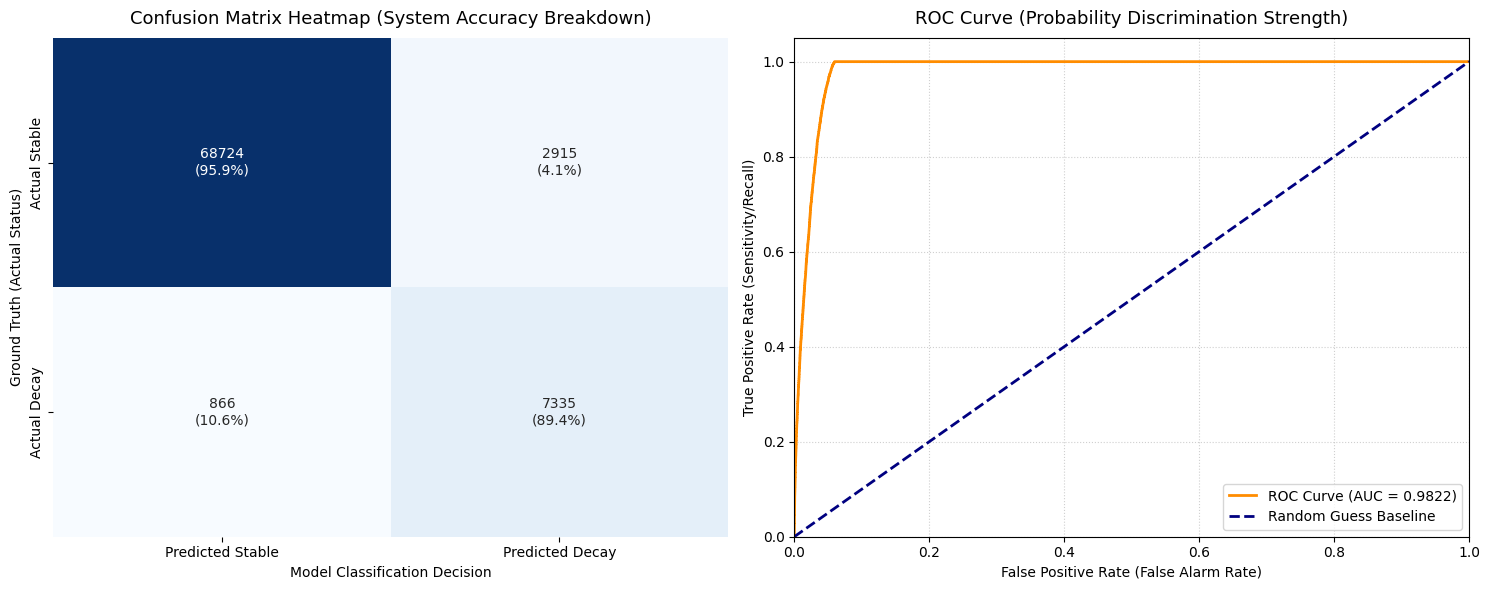


--- TEXTUAL PERFORMANCE SUMMARY ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     71639
           1       0.72      0.89      0.80      8201

    accuracy                           0.95     79840
   macro avg       0.85      0.93      0.88     79840
weighted avg       0.96      0.95      0.95     79840



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

print("Step 1: Training the Random Forest model on 319,356 rows...")
# Using n_jobs=-1 speeds this up by using all your computer's CPU cores
model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 2. Get predictions and raw probabilities for testing
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nStep 2: Generation of Visual System Diagnostic Metrics...")

# Create a clean side-by-side plotting dashboard
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- DIAGRAM 1: CONFUSION MATRIX HEATMAP ---
cm = confusion_matrix(y_test, y_pred)
# Normalize to show exact percentage distributions within each true category
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

labels = np.asarray([f"{val}\n({pct:.1f}%)" for val, pct in zip(cm.flatten(), cm_percent.flatten())]).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=['Predicted Stable', 'Predicted Decay'],
            yticklabels=['Actual Stable', 'Actual Decay'])
axes[0].set_title("Confusion Matrix Heatmap (System Accuracy Breakdown)", fontsize=13, pad=10)
axes[0].set_ylabel("Ground Truth (Actual Status)")
axes[0].set_xlabel("Model Classification Decision")

# --- DIAGRAM 2: ROC CURVE (TRAINING QUALITY) ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess Baseline')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (False Alarm Rate)')
axes[1].set_ylabel('True Positive Rate (Sensitivity/Recall)')
axes[1].set_title('ROC Curve (Probability Discrimination Strength)', fontsize=13, pad=10)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Print the standard text output alongside it
print("\n--- TEXTUAL PERFORMANCE SUMMARY ---")
print(classification_report(y_test, y_pred))

Step 1: Initializing competing models...
Training Random Forest Base on 319356 rows...
-> Random Forest Base achieved a Validation ROC-AUC Score: 0.9821
Training LightGBM Classifier on 319356 rows...
-> LightGBM Classifier achieved a Validation ROC-AUC Score: 0.9824
Training Gradient Boosting on 319356 rows...
-> Gradient Boosting achieved a Validation ROC-AUC Score: 0.9823


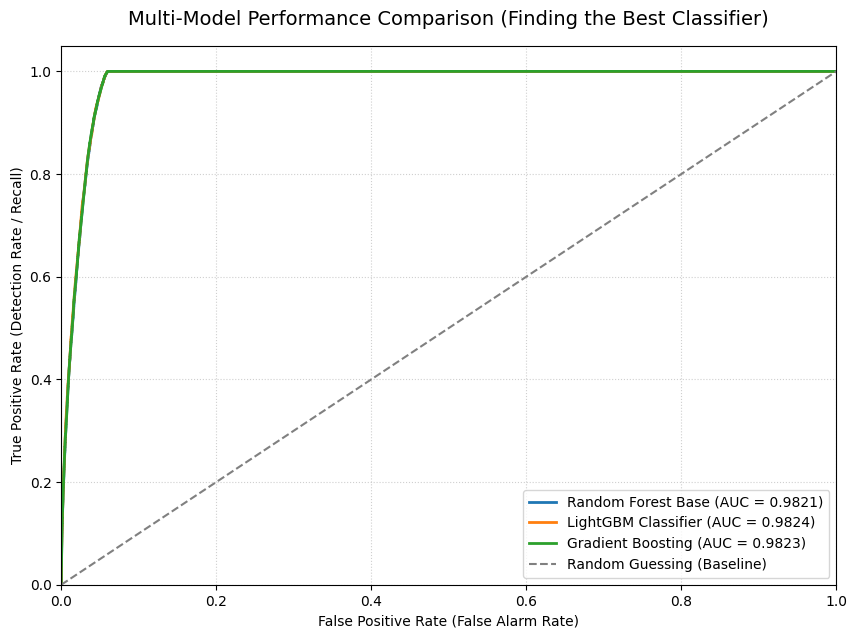

In [14]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import lightgbm as lgb 

print("Step 1: Initializing competing models...")

models = {
    "Random Forest Base": RandomForestClassifier(max_depth=12, n_estimators=50, random_state=42, n_jobs=-1),
    "LightGBM Classifier": lgb.LGBMClassifier(max_depth=8, n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
    "Gradient Boosting": GradientBoostingClassifier(max_depth=5, n_estimators=50, random_state=42)
}

plt.figure(figsize=(10, 7))

# Step 2: Loop through each model, train it, test it, and plot its performance curve
for name, model in models.items():
    print(f"Training {name} on {X_train.shape[0]} rows...")
    model.fit(X_train, y_train)
    
    # Predict raw probabilities for the decay class (1)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"-> {name} achieved a Validation ROC-AUC Score: {auc:.4f}")
    
    # Compute points for the curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.4f})')

# Plot styling configuration
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (Baseline)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarm Rate)')
plt.ylabel('True Positive Rate (Detection Rate / Recall)')
plt.title('Multi-Model Performance Comparison (Finding the Best Classifier)', fontsize=14, pad=15)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [15]:
import pandas as pd
import numpy as np

print("Generating operational Content Opportunity Scores using the Champion LightGBM Model...")

# 1. Predict the continuous probability of performance decay across the test pool
# [:, 1] extracts the specific probability of belonging to Class 1 (Decaying)
df_validation_results = X_test.copy()
df_validation_results['decay_probability'] = models["LightGBM Classifier"].predict_proba(X_test)[:, 1]

# 2. Map back the tracking hash IDs so we know exactly which websites and pages these belong to
df_dashboard = df_validation_results.join(df_train[['client_hash_id', 'content_hash_id']])

# 3. Create the operational Content Opportunity Score (Scaled 0 to 100 for easy business interpretation)
df_dashboard['opportunity_score'] = (df_dashboard['decay_probability'] * 100).round(1)

# 4. Sort by the highest score so the urgent content refresh priorities sit right at the top
df_dashboard_sorted = df_dashboard[[
    'client_hash_id', 'content_hash_id', 'opportunity_score', 
    'avg_position', 'ctr', 'engagement_rate', 'scrolls_per_session'
]].sort_values(by='opportunity_score', ascending=False)

print("\n🚀 Priority Content Refresh Dashboard (Top 10 Most Critical Assets):")
display(df_dashboard_sorted.head(10))

Generating operational Content Opportunity Scores using the Champion LightGBM Model...

🚀 Priority Content Refresh Dashboard (Top 10 Most Critical Assets):


,client_hash_id,content_hash_id,opportunity_score,avg_position,ctr,engagement_rate,scrolls_per_session
49912,client_1a730cb2640a1abf,content_2039fb0bed3d9f1f,99.7,16.813619,0.032875,0.079395,0.241966
51180,client_1a730cb2640a1abf,content_6beec5e89ab8bdb2,99.7,16.813619,0.032875,0.079395,0.241966
52432,client_1a730cb2640a1abf,content_b69403dd0786961f,99.7,16.813619,0.032875,0.079395,0.241966
52500,client_1a730cb2640a1abf,content_bbeb2bcbdf689955,99.7,16.813619,0.032875,0.079395,0.241966
52803,client_1a730cb2640a1abf,content_cd37b4cb022f2c18,99.7,16.813619,0.032875,0.079395,0.241966
51986,client_1a730cb2640a1abf,content_9b61eb6930cb9108,99.7,16.813619,0.032875,0.079395,0.241966
53583,client_1a730cb2640a1abf,content_ff85cddb7e3ab4a0,99.7,16.813619,0.032875,0.079395,0.241966
51477,client_1a730cb2640a1abf,content_7cd7858128894e29,99.7,16.813619,0.032875,0.079395,0.241966
52319,client_1a730cb2640a1abf,content_af4ab186af7df689,99.7,16.813619,0.032875,0.079395,0.241966
53389,client_1a730cb2640a1abf,content_f28e00872dea3d8b,99.7,16.813619,0.032875,0.079395,0.241966


In [16]:
import pickle
import os

print("--- INITIALIZING MULTI-MODEL SERIALIZATION ---")

# Define clear, readable file names for each framework
model_files = {
    "LightGBM Classifier": "champion_lightgbm_decay_model.pkl",
    "Random Forest Base": "baseline_random_forest_model.pkl",
    "Gradient Boosting": "gradient_boosting_decay_model.pkl"
}

# Loop through your trained models dictionary and dump them to disk
for model_name, filename in model_files.items():
    if model_name in models:
        print(f"Serializing and saving {model_name}...")
        with open(filename, 'wb') as file:
            pickle.dump(models[model_name], file)
        print(f"  └─ Saved successfully to: {os.path.abspath(filename)}")
    else:
        print(f"⚠️ Warning: {model_name} was not found in your models dictionary.")

print("\n🚀 All 3 models have been safely preserved in your working directory!")

--- INITIALIZING MULTI-MODEL SERIALIZATION ---
Serializing and saving LightGBM Classifier...
  └─ Saved successfully to: C:\Users\msen6\Documents\Internship\FlyRank\flyrank_internship_repo\submission\Capstone\champion_lightgbm_decay_model.pkl
Serializing and saving Random Forest Base...
  └─ Saved successfully to: C:\Users\msen6\Documents\Internship\FlyRank\flyrank_internship_repo\submission\Capstone\baseline_random_forest_model.pkl
Serializing and saving Gradient Boosting...
  └─ Saved successfully to: C:\Users\msen6\Documents\Internship\FlyRank\flyrank_internship_repo\submission\Capstone\gradient_boosting_decay_model.pkl

🚀 All 3 models have been safely preserved in your working directory!
